In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as col
import Bayesian_Methods as Bayes
import Parameters as Pars
from Two_Par_Variation import TwoDimParVar

In [3]:
#par1 = Pars.psi0
#par2 = Pars.m0
#ranges = dict([par1, par2])
par1 = (Pars.psi0[0],np.array((-1.5,-1.75)))
par2 = (Pars.m0[0],np.linspace(10.5,15,20))
ranges = dict([par1, par2])

In [4]:
locpdf = 'hc_PDF'
lochc = 'Data'
DistObj = Bayes.Distribution(ranges) #Initialize Distribution Object for the pre-defined parameters
PDF = DistObj.PDF(DistObj) #Create a pdf object from the given distribution object
pdf = PDF.load_pdf(locpdf) #Obtain the pdf distribution as an array
PDF.dim_names = np.array(('Frequencies', 'Realisations', 'Loudest')) #Set the name of the dimensions of the PDF to the dimensions of holodeck

The pdf of the independent parameter hc_ss given the parameters ['psi0', 'm0'] has been set


In [5]:
Priors = DistObj.Priors(DistObj)
U = Priors.Uniform()
Priors.log = False

In [6]:
MCI = DistObj.MCI(Priors,PDF)
MCI.apply_prior()
MCI.Integration('Realisations') #Yields the likelihood

array([[[[1.77412624, 1.77350025, 1.77336239, 1.77330133, 1.77327472],
         [3.04747273, 3.0462315 , 3.04591939, 3.04575597, 3.04569978],
         [3.29495333, 3.29019041, 3.2896566 , 3.28941015, 3.28922804],
         ...,
         [0.53716263, 0.537152  , 0.53715039, 0.53714984, 0.53714954],
         [0.59469633, 0.59469675, 0.5946968 , 0.59469682, 0.59469682],
         [0.60072329, 0.60072346, 0.60072347, 0.60072348, 0.60072348]],

        [[1.77771952, 1.77505433, 1.77453172, 1.77415609, 1.77392688],
         [3.05323794, 3.04826783, 3.04717024, 3.04677438, 3.04655809],
         [3.30444607, 3.29397986, 3.2920347 , 3.29099528, 3.29057534],
         ...,
         [0.53722177, 0.53715783, 0.53715272, 0.53715127, 0.53715074],
         [0.59469557, 0.59469666, 0.59469674, 0.59469677, 0.59469679],
         [0.6007229 , 0.60072338, 0.60072343, 0.60072346, 0.60072346]],

        [[1.79365554, 1.78140225, 1.77813518, 1.77689368, 1.77606038],
         [3.06957495, 3.05501668, 3.05146919,

In [9]:
np.shape(FreqJoinedpdf)

(2, 20, 5)

In [10]:
Joinedpdf1 = DistObj.Joint_distribution(MCI) #Initialize a joint distribution object starting from a pre-existing distribution
FreqJoinedpdf = Joinedpdf1.joindiag('Frequencies') #pdf array + setting of joint distribution in Joinedpdf1 object (across frequencies)
Joinedpdf2 = DistObj.Dimensional_Projection(Joinedpdf1) #Initialize a joint distribution object starting from a pre-existing distribution
FreqLoudestJoinedpdf = [Joinedpdf2.project('Loudest',i) for i in np.arange(5)] #pdf array + setting of joint distribution in Joinedpdf1 object (across all loudest sources)

Converting to log-space to avoid overflow


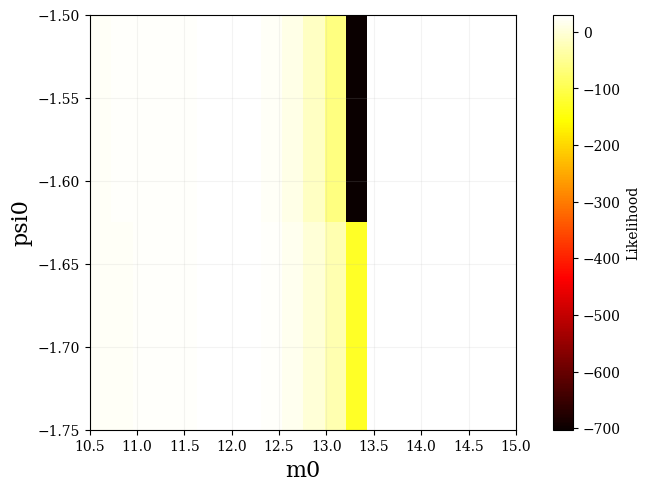

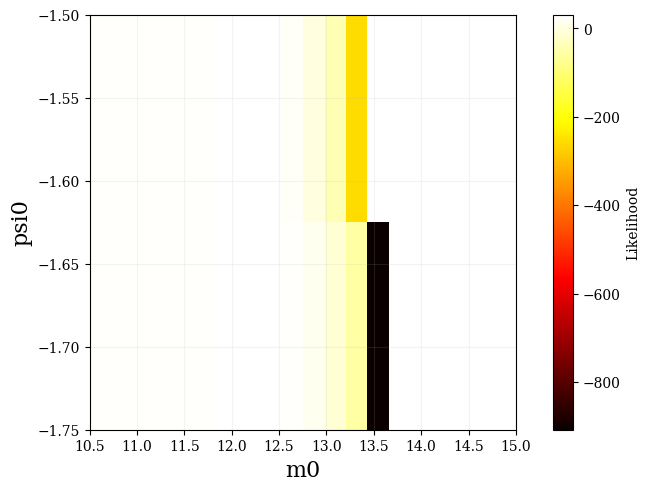

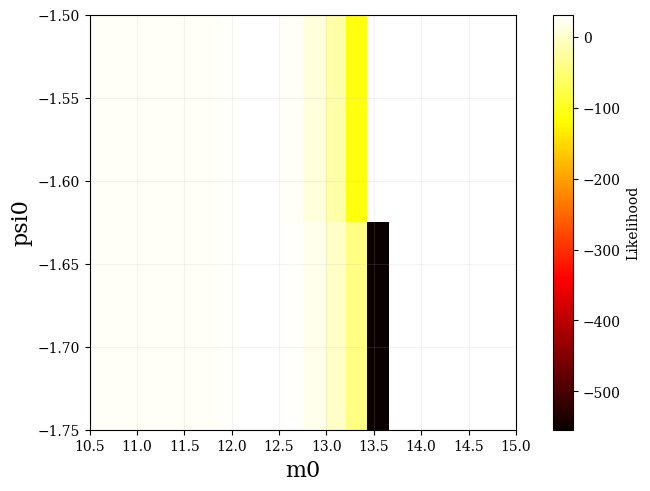

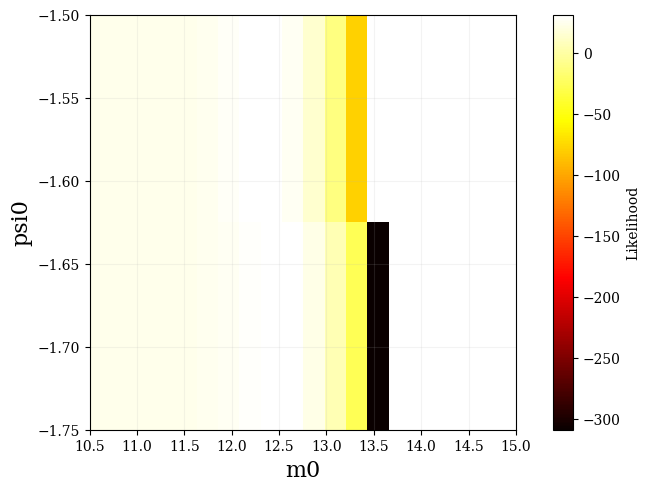

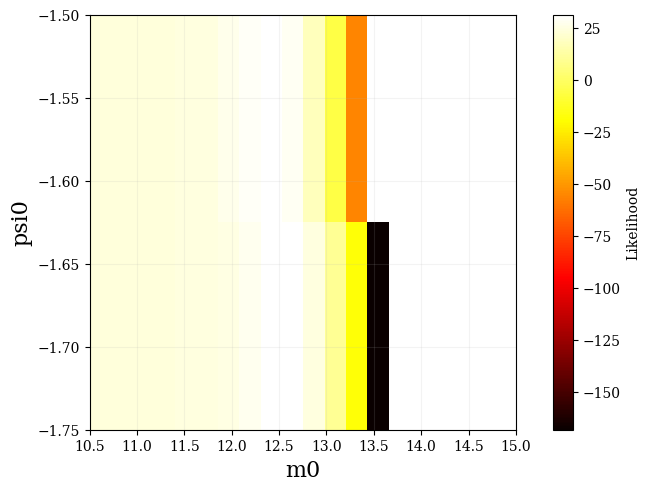

In [11]:
for i in np.arange(5): 
    figs, ax = plt.subplots(layout='constrained')
    figsize=(16,4)
    im = ax.imshow(FreqLoudestJoinedpdf[i], cmap='hot', interpolation='nearest',extent = (list(DistObj.parameters)[1][0],list(DistObj.parameters)[1][-1],list(DistObj.parameters)[0][-1],list(DistObj.parameters)[0][0]), aspect = 'auto')
    ax.set_xlabel(DistObj.par_names[1],fontsize=16)
    ax.set_ylabel(DistObj.par_names[0],fontsize=16)
    figs.colorbar(im,label='Likelihood')
    plt.savefig(f'{i+1} loudest smbhb likelihoods.png')
    plt.show()

In [12]:
Joinedpdf3 = DistObj.Joint_distribution(Joinedpdf1) #Initialize a joint distribution object starting from a pre-existing distribution
FreqLoudJoinedpdf = Joinedpdf3.joindiag('Loudest')

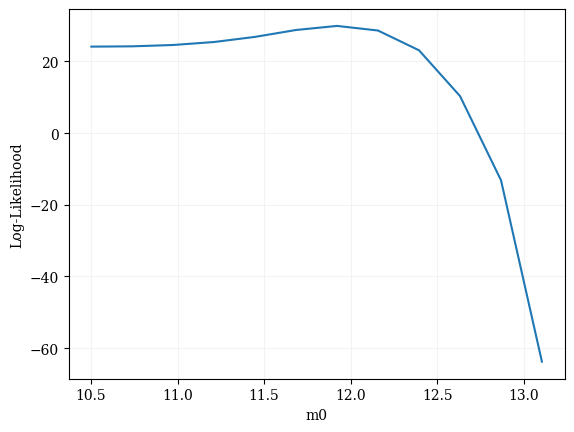

In [33]:
plt.plot(Joinedpdf3.parameters[1][:12],FreqLoudestJoinedpdf[0][0][:12])
plt.xlabel('m0')
plt.ylabel('Log-Likelihood')
plt.savefig('1-Par extended')

In [25]:
np.shape(FreqLoudestJoinedpdf[0])

(2, 20)

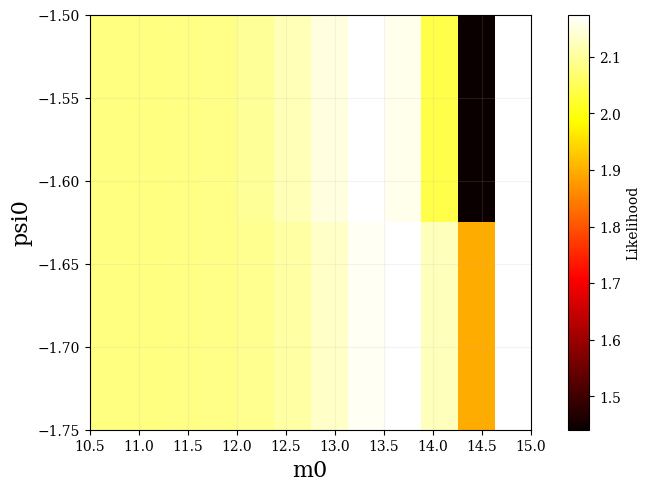

In [42]:
figs, ax = plt.subplots(layout='constrained')
figsize=(16,4)
im = ax.imshow(np.log10(FreqLoudJoinedpdf[:,:12]), cmap='hot', interpolation='nearest',extent = (list(DistObj.parameters)[1][0],list(DistObj.parameters)[1][-1],list(DistObj.parameters)[0][-1],list(DistObj.parameters)[0][0]), aspect = 'auto')
ax.set_xlabel(DistObj.par_names[1],fontsize=16)
ax.set_ylabel(DistObj.par_names[0],fontsize=16)
figs.colorbar(im,label='Likelihood')
plt.show()

In [41]:
np.shape(FreqLoudJoinedpdf[:,:12])

(2, 12)